# CoLA Velocity Fields

In this notebook, we will be implementing a displacement gradient when a cortical laser ablation cut is made to a cell. This displacement field can then later be used to advect the actomyosin cortex.

In [2]:
import numpy as np

from IPython.display import HTML
from tqdm import tqdm

Make sure to run `pip install -e .` before running the cell below. This command will make sure `diet4cola` is installed as a module in your current Python/Conda environment.

In [3]:
from diet4cola.generation.cola import CoLACut
from diet4cola.generation.masks import cell_mask
from diet4cola.generation.noise import myosin_noise, actin_noise
from diet4cola.generation.operations import add, mul, normalize
from diet4cola.sdf import sdf_segment, sdf_capsule, compute_sdf

from diet4cola.utils import *

## Synthetic Actomyosin Cortex and CoLA Cut

As before, we start with creating a synthetic actomyosin cortex, followed by a CoLA cut.

In [4]:
# Cell parameters
seed = 42
width = 512
height = 512

np.random.seed(seed)
off_x = 256 + (np.random.randint(32) - 16)
off_y = 256 + (np.random.randint(32) - 16)

In [5]:
def generate_cell_layer() -> tuple[np.ndarray, tuple[int, int], float]:
    # Cell mask
    cell_mask_layer, (cell_extent_a, cell_extent_b), cell_angle = cell_mask(width, height, (off_x, off_y), (200, 200), 50, seed)

    return (cell_mask_layer, (cell_extent_a, cell_extent_b), cell_angle)

def generate_actomyosin_cortex(cell_mask_layer: np.ndarray) -> np.ndarray:
    # Myosin layer
    myosin_layer        = myosin_noise(width, height, seed = seed, iterations=10)
    myosin_layer        = mul(myosin_layer, cell_mask_layer)

    # Actin layer
    actin_layer         = actin_noise(width, height, cell_mask_layer, 2560, -0.05, seed)
    actin_layer         = mul(actin_layer, cell_mask_layer)

    # Combine myosin and actin layers into actomyosin
    actomyosin_layer    = add(myosin_layer, actin_layer)
    actomyosin_layer    = normalize(actomyosin_layer)

    return actomyosin_layer

In [6]:
cell_mask_layer, (cell_extent_a, cell_extent_b), cell_angle = generate_cell_layer()

In [7]:
#actomyosin_layer = generate_actomyosin_cortex(cell_mask_layer)
#save_cortex(actomyosin_layer, './data/cortex_1')

For now, we will simply load the example cortex obtained from a [previous notebook](./artificial_cola.ipynb).

In [8]:
actomyosin_layer = load_cortex('./data/cortex_1.npy')

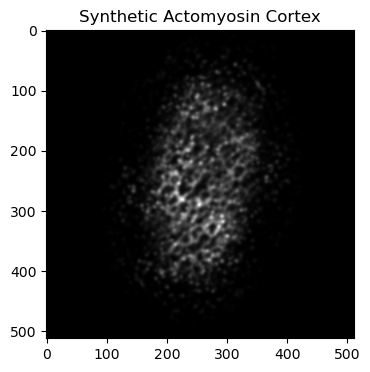

In [9]:
plot_2d_array(actomyosin_layer, 'Synthetic Actomyosin Cortex')

In [10]:
cola_cut = CoLACut((off_x, off_y), 32, 150, seed)

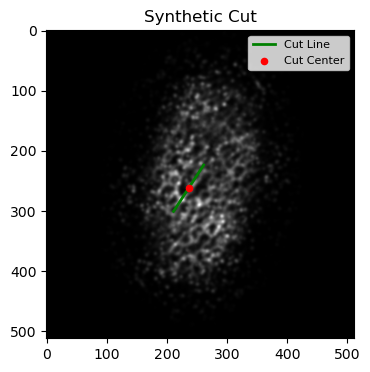

In [11]:
plot_synthetic_cut(actomyosin_layer, 
                   cola_cut.cut_center, 
                   cola_cut.cut_origin,
                   cola_cut.cut_destination)

## Velocity Model

The next important step is to decide how we are going to model the advection (i.e. how the cut evolves over time). From the provided original data, we have seen that the velocity is distinct in two ways:

- All points move away from the cut, following a specific distribution (expected to be exponential/hyperbolic)
- Points further away from the cut, will have an smaller initial velocity. The initial velocity decays exponentially with increasing distance to the cut.

A simple velocity model that captures these points is the following:

$$ \bold{v}(\bold{r}, t) = v_0(d, t)\bold{n}(\bold{x}, t) $$

where $\bold{r} = (x, y)$ the position of a point, $t$ represents the temporal dimension. Here we can choose different functions to model the initial velocity $v_0$ such as

- Exponential: $v_0(d, t) = A(t)e^{-d/\lambda}$
- Hyperbolic: $v_0(d, t) = A(t)\frac{1}{1 + (d/\lambda)^p}$

where $A(t)$ represents the amplitude of the velocity field at time $t$, $d$ the distance to the cut, $\lambda$ the decay-length scale (i.e. how quickly velocity decreases with distance) and $p$ a hyperparameter.

### Initial Velocity Field

Given some simple parameter choices, we can construct the velocity field based on the [Segment SDF](../diet4cola/sdf.py).

In [12]:
width, height = actomyosin_layer.shape
cut_sdf = compute_sdf(width, height, cola_cut.cut_origin, cola_cut.cut_destination, 0, sdf_segment)

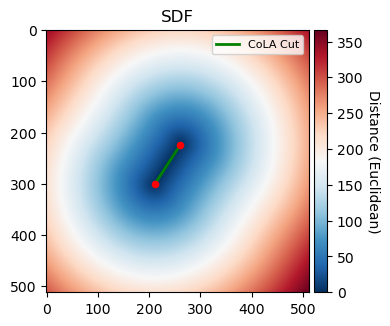

In [13]:
plot_sdf(cut_sdf, cola_cut.cut_origin, cola_cut.cut_destination, cmap='RdBu_r')

Let's use the following velocity model:

$$ v_0(d, t) = \frac{1}{t}e^{-d/\lambda} $$

In [14]:
def velocity_model(d: float = 0.0, l: float = 1.0, t: float = 0.0) -> float:
    return (1 / t) * np.exp(-d / l)

And create the velocity field.

In [15]:
def velocity_field(sdf: np.ndarray, l: float = 1.0, t: float = 0.0) -> np.ndarray:
    width, height = sdf.shape
    data = np.zeros([height, width])

    for y in range(height):
        for x in range(width):
            data[y, x] = velocity_model(sdf[y, x], l, t)

    return data

In [16]:
vf = velocity_field(cut_sdf, 40, 1)

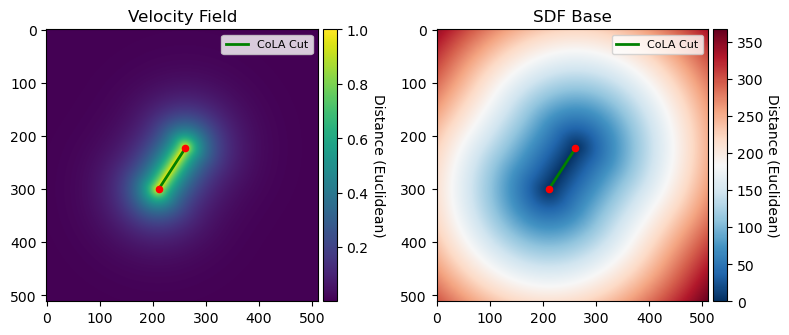

In [17]:
plot_velocity_field(vf, cut_sdf, cola_cut.cut_origin, cola_cut.cut_destination)

We can animate this!

In [18]:
from matplotlib.animation import FuncAnimation

def animate_arrays(data: np.ndarray, 
                   origin: tuple[int, int],
                   destination: tuple[int, int],
                   interval: int = 200, 
                   cmap='viridis'):
    # Check input
    if not isinstance(data, np.ndarray):
        raise TypeError("data must be a 3D NumPy array")
    if data.ndim != 3:
        raise ValueError(f"data must be 3D, got {data.ndim}D")
    if data.size == 0:
        raise ValueError("data cannot be empty")
    
    num_frames = data.shape[0]

    # Global min and max for consistent color scaling
    vmin, vmax = data.min(), data.max()
    
    fig, ax = plt.subplots()
    img = ax.imshow(data[0], cmap=cmap, vmin=vmin, vmax=vmax)
    ax.axis('off')  

    # Plot the origin–destination line in green
    ax.plot(
        [origin[0], destination[0]], 
        [origin[1], destination[1]], 
        color='green', linewidth=2, label='CoLA Cut', zorder=1
    )

    # Plot origin and destination points in red
    ax.scatter(*origin, color='red', s=20, zorder=2)
    ax.scatter(*destination, color='red', s=20, zorder=2)

    # Add colorbar
    cbar = fig.colorbar(img, ax=ax)

    def update(frame):
        img.set_data(data[frame])
        return [img]

    anim = FuncAnimation(fig, update, frames=num_frames, interval=interval, blit=True)
    return anim

In [19]:
fields = []
iterations = 10
step = 0.1
t = 0.1

for i in tqdm(range(iterations)):
    vf = velocity_field(cut_sdf, 40, t)
    fields.append(vf)

    t = t + step

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:01<00:00,  5.08it/s]


In [20]:
fields = np.array(fields)
fields.shape

(10, 512, 512)

In [21]:
anim = animate_arrays(np.array(fields), cola_cut.cut_origin, cola_cut.cut_destination)

# Display animation inline
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(anim.to_jshtml())
plt.close(anim._fig)  # <-- closes the figure so the static plot doesn't show
html_anim

We can also try to do this for an SDF like a capsule that gets bigger over time.

In [22]:
fields = []
iterations = 50
step = 0.01
t = 0.1

for i in tqdm(range(iterations)):
    width = 4 * i
    capsule_sdf = compute_sdf(512, 512, cola_cut.cut_origin, cola_cut.cut_destination, width, sdf_capsule)

    # Clip the SDF to 0-values
    capsule_sdf = np.where(capsule_sdf < 0, np.max(capsule_sdf), capsule_sdf)

    vf = velocity_field(capsule_sdf, 40, t)
    fields.append(vf)

    #plot_velocity_field(vf, capsule_sdf, cola_cut.cut_origin, cola_cut.cut_destination)

    t = t + step

fields = np.array(fields)
fields.shape

100%|██████████| 50/50 [01:30<00:00,  1.81s/it]


(50, 512, 512)

In [23]:
anim = animate_arrays(np.array(fields), cola_cut.cut_origin, cola_cut.cut_destination)

# Display animation inline
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(anim.to_jshtml())
plt.close(anim._fig)  # <-- closes the figure so the static plot doesn't show
html_anim